# Depth first search, solution

Load code and data for countries, cities, and roads, which form a symmetric weighted graph.

See also https://en.wikipedia.org/wiki/Depth-first_search .

In [1]:
import os
#print(os.getcwd())

from roadbox import Country, City, Road
from roadbox import show_map, show_path

In [2]:
with open(f"countries.py", 'r', encoding="utf8") as file:
    countries = eval(file.read())

with open(f"cities.py", 'r', encoding="utf8") as file:
    cities = eval(file.read())

with open(f"roads.py", 'r', encoding="utf8") as file:
    roads = eval(file.read())

with open(f"example_paths.py", 'r', encoding="utf8") as file:
    example_paths = eval(file.read())

In [3]:
def create_map(roads):
    '''creates an adjacency map'''

    # For every road, you need to add the road to the adjacency map in both directions.
    # If a and b are the cities, then adjacnecy_map[a][b] = distance and 
    # adjacency_map[b][a] = distance

    adjacency_map = {}

    for road in roads:
        
        if not road.a in adjacency_map:
            adjacency_map[road.a] = {}
        adjacency_map[road.a][road.b] = road.distance

        if not road.b in adjacency_map:
            adjacency_map[road.b] = {}  
        adjacency_map[road.b][road.a] = road.distance

    return adjacency_map

adjacency_map = create_map(roads)

## Depth-first seach

Search a possible path between any two cities **a** and **b** by using depth-first search with Taboo-list.

To create the algorithm, start by adding the head **a** to the path.

Then, extend the path by choosing a random neighbor of **a** and a random neighbor of that neighbor, and so on, with the following restrictions:

- do not add a neighbor that is already on the current path.
- do not add a neighbor that is in the Taboo-list (which is initially empty).

When you hit a dead end without having found the destination **b**, **backtrack** along the existing path. Starting at the current tail, each city on the path that does not have a neighbor that is not itself part of the path and that is not in the Taboo-list is deleted from the path and added to the Taboo list, until you find a city that has an as of yet unexplored neighbor. Now, extend the path by adding neighbors as before.

In [ ]:
def depth_first(adjacency_map, origin, destination):
    """Returns a path from origin to destination if it exists. Origin and destination 
    are the indices of cities. The function returns a path, which is a list of nodes 
    that includes both origin and the destination. It returns an empty list otherwise."""

    # We are implementing depth first search. 
    #
    # Starting at the origin, we create a path by adding a node to the path that 
    # is connected to the last node of the current path. 
    #
    # We do not add nodes to the path that are either already on the path or in a taboo list. 
    #
    # The taboo list is initially empty.
    # 
    # If we add a node that turns out to be the destination, we are done.
    #
    # If we have added a node n to the path that has no neighbor that is neither on the 
    # current path nor in the taboo list, in other words, if we have reached a dead end,
    # we add n to the taboo list, backtrack by popping n from the current path, and try 
    # again from what is now the last node. 

    path = [] 
    taboo = set()     # this can also be a list

    path.append(origin)

    while len(path) > 0 and path[-1] != destination:

        current = path[-1]

        next = None

        for neighbor in adjacency_map[current]:
            if (neighbor not in path) and (neighbor not in taboo):
                next = neighbor
                break

        if next is None:
            taboo.add(current)   # taboo.append(current) when taboo is a list
            path.pop()
            
        else: 
            path.append(next)
  
    return path

path length in number of nodes: 188
path length in km: 18699.0


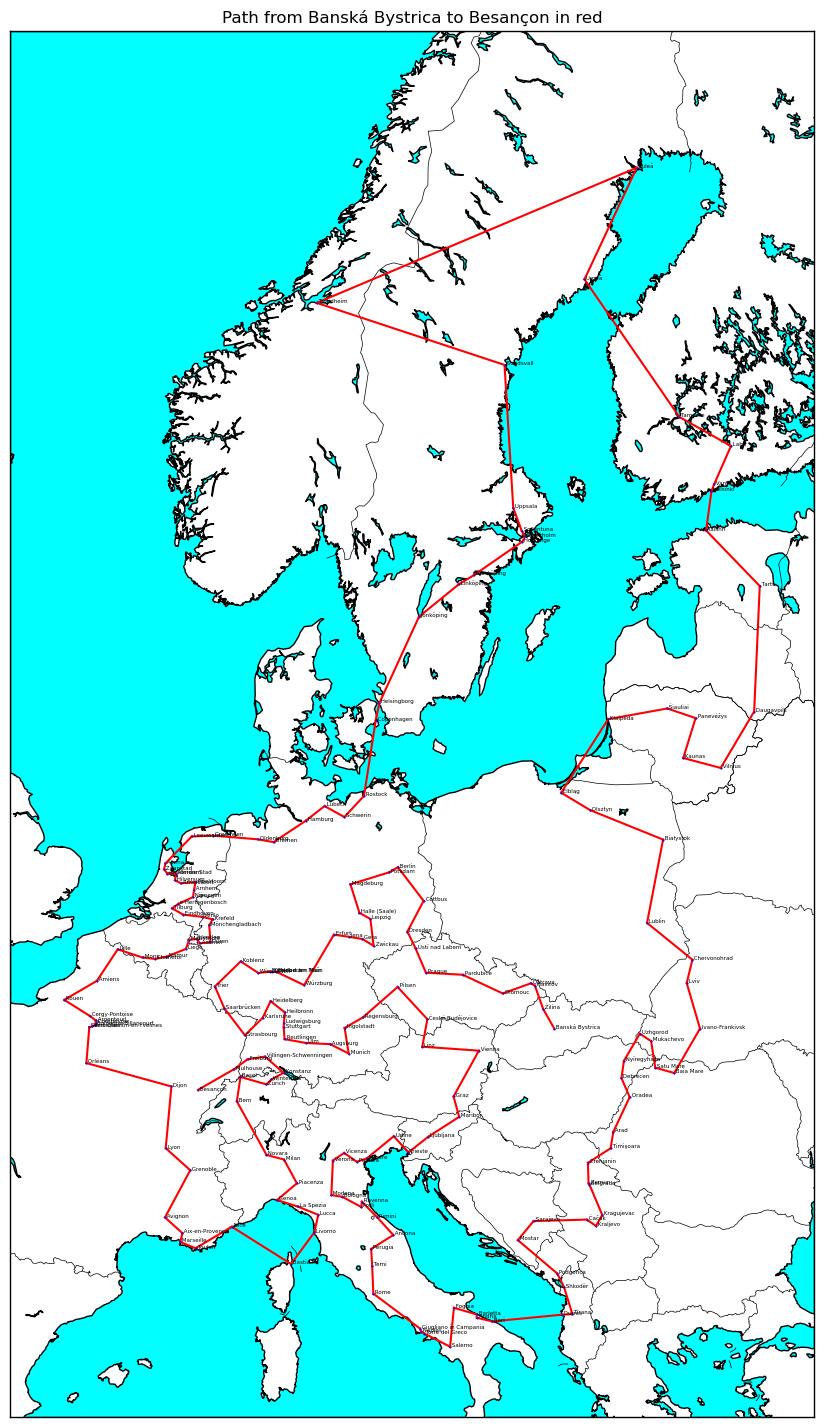

In [5]:
path = depth_first(adjacency_map, 41, 63)

show_path(cities, path, adjacency_map)

The red path above is the path found with depth first. Note how long it is.